This is a notebook for computing deep foundation axial geotechnical capacity. <br>
Author: Zhiyan Jiang [(linkedin.com/in/zhiyanjiang)](http://www.linkedin.com/in/zhiyanjiang)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import yaml

In [3]:
from deep_foundation_bearing_capacity.cross_sections.cross_sections import CircularSection, CrossSection
from deep_foundation_bearing_capacity.factor_of_safety.factor_of_safety import FactorOfSafetyDeepFoundation
from deep_foundation_bearing_capacity.foundation.deep_foundation import DeepFoundation
from deep_foundation_bearing_capacity.foundation.foundation_material import FoundationConcrete
from deep_foundation_bearing_capacity.geomaterials.layer import Layer
from deep_foundation_bearing_capacity.geomaterials.rock import Rock
from deep_foundation_bearing_capacity.geomaterials.soil import Soil
from deep_foundation_bearing_capacity.segments.segments import Segment
from deep_foundation_bearing_capacity.segments.unit_resistance import SideResistance, SoilEndResistance

In [4]:
def _find_project_root(marker = "pyproject.toml"):
    p = Path.cwd().resolve()
    while p != p.parent:
        if (p / marker).exists():
            return p
        else:
            p = p.parent
    raise FileNotFoundError(f"No {marker} found")

PROJECT_ROOT = _find_project_root()
#print(f"Project root is: {PROJECT_ROOT}")

In [5]:
# Read soil parameters from YAML
with open(PROJECT_ROOT/"data/soil_params.yaml") as f:
    soils_dict = yaml.safe_load(f)

soil_list = []
for soil_dict in soils_dict:
    soil_dict = Soil.from_dict(soil_dict)
    soil_list.append(soil_dict)

    soil_dict.display_properties()
    print()
    

soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 5

soil_index is: 1
unit_weight is: 120.0
cohesion is: 500.0
friction_angle is: 0.0
n60 is: 16

soil_index is: 2
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 17

soil_index is: 3
unit_weight is: 115.0
cohesion is: 2000.0
friction_angle is: 0.0
n60 is: 18

soil_index is: 4
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 19

soil_index is: 5
unit_weight is: 130.0
cohesion is: 4000.0
friction_angle is: 0.0
n60 is: 20

soil_index is: 6
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 21

soil_index is: 7
unit_weight is: 130.0
cohesion is: 200.0
friction_angle is: 0.0
n60 is: 22

soil_index is: 8
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 23

soil_index is: 9
unit_weight is: 130.0
cohesion is: 8000.0
friction_angle is: 0.0
n60 is: 24

soil_index is: 10
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 30

In [6]:
# Read layer parameters from YAML

with open(PROJECT_ROOT/"data/layer_params.yaml") as f:
    layers_dict = yaml.safe_load(f)


layer_list = []
for layer_dict in layers_dict:
    layer = Layer.from_dict(layer_dict)
    layer_list.append(layer)

# Manually assign geomaterial
for layer, soil in zip(layer_list, soil_list):
    layer.geomaterial = soil

for layer in layer_list:
    layer.display_properties(display_geomaterial = True)
    print()

layer_index is: 0
ground_water_depth is: 15.0
top_depth is: 0
thickness is: 10
soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 5

layer_index is: 1
ground_water_depth is: 15.0
top_depth is: 10
thickness is: 5
soil_index is: 1
unit_weight is: 120.0
cohesion is: 500.0
friction_angle is: 0.0
n60 is: 16

layer_index is: 2
ground_water_depth is: 15.0
top_depth is: 15
thickness is: 10
soil_index is: 2
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 17

layer_index is: 3
ground_water_depth is: 15.0
top_depth is: 25
thickness is: 10
soil_index is: 3
unit_weight is: 115.0
cohesion is: 2000.0
friction_angle is: 0.0
n60 is: 18

layer_index is: 4
ground_water_depth is: 15.0
top_depth is: 35
thickness is: 10
soil_index is: 4
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 19

layer_index is: 5
ground_water_depth is: 15.0
top_depth is: 45
thickness is: 10
soil_index is: 5
unit_weight is: 130.0
cohesion is: 4000.0
fric

In [7]:
# test SideResistance class for cohesionless layer
side_resistance_obj_1 = SideResistance.for_material(layer_list[0])
print(f"First layer beta is: {side_resistance_obj_1._calculate_beta(600):.2f}")
print(f"First layer phi prime is: {side_resistance_obj_1._calculate_phi_prime(600)}")
print(f"First layer ko is: {side_resistance_obj_1._calculate_ko(600)}")
print(f"First layer ko is: {side_resistance_obj_1.side_resistance_unit(600)}")

# test SideResistance class for cohesive layer
side_resistance_obj_2 = SideResistance.for_material(layer_list[1])
print(f"Second layer alpha is: {side_resistance_obj_2._calculate_alpha():.2f}")

First layer beta is: 0.57
First layer phi prime is: 32.70987923634994
First layer ko is: 0.8809471432730439
First layer ko is: 339.46352410536963
Second layer alpha is: 0.55


In [8]:
# test EndResistance class for cohesionless layer
end_resistance_obj_1 = SoilEndResistance(layer_list[0])
print(f"Top layer unit end resistance is: {end_resistance_obj_1.end_resistance_unit():.2f}")

Top layer unit end resistance is: 6000.00


In [9]:
# test EndResistance class for cohesionless layer
end_resistance_obj_2 = SoilEndResistance(layer_list[1])
print(f"Second layer unit end resistance is: {end_resistance_obj_2.end_resistance_unit():.2f}")

Second layer unit end resistance is: 3250.00


In [10]:
# test CrossSection class
cross_section_diameter = 1.5
print(f"Cross section diameter is: {cross_section_diameter}")
cross_section_obj = CircularSection(1.5)
print(f"Cross section area is: {cross_section_obj.cross_section_area:.2f}")
print(f"Cross section perimeter is: {cross_section_obj.perimeter:.2f}")

Cross section diameter is: 1.5
Cross section area is: 1.77
Cross section perimeter is: 4.71


In [11]:
# test Segment class
segment_obj_list = []
foundation_concrete_obj = FoundationConcrete()

for layer in layer_list:
    segment_obj = Segment(cross_section_obj, layer, foundation_concrete_obj)
    segment_obj_list.append(segment_obj)



In [12]:
print(f"Top segment side surface area is: {segment_obj_list[0].side_surface_area:.2f}")

Top segment side surface area is: 47.12


In [13]:
# test DeepFoundation class
top_depth = 0

deep_foundation_obj = DeepFoundation(segment_obj_list, top_depth,  resistance_corrections = None)

# test DeepFoundation method for self weight
print(f"Concrete foundation self weight is: {deep_foundation_obj.effective_weight:.0f} lb.")

Concrete foundation self weight is: 19456 lb.


In [14]:
# test DeepFoundation method for calculating effective stress
print(f"Deep foundation effective stresses are: {deep_foundation_obj.calculate_segment_effective_stresses}")

Deep foundation effective stresses are: [600.0, 1500.0, 2063.0, 2589.0, 3190.0, 3866.0, 4542.0, 5218.0, 5894.0, 6570.0, 7171.0, 7722.0]


In [15]:
# test FactorOfSafety class
fs = 3.0
print(f"Factor of safety is prescribed as: {fs}")
fs_obj = FactorOfSafetyDeepFoundation(3, 3)

Factor of safety is prescribed as: 3.0


In [16]:
# test DeepFoundation side resistance
deep_foundation_obj.calculate_segment_side_resistances(uplift = False)

[np.float64(15996.841702366963),
 np.float64(26798.60831473337),
 np.float64(61360.00787224347),
 np.float64(68424.8968236852),
 np.float64(75835.53836755692),
 np.float64(83592.12811454642),
 np.float64(91192.0778328152),
 np.float64(98683.03884276563),
 np.float64(106094.31520255811),
 np.float64(113445.1354149876),
 np.float64(120284.11395452406),
 np.float64(126789.71405531435)]

In [17]:
# test DeepFoundation side resistance
deep_foundation_obj.calculate_segment_side_resistances(uplift = True)

[np.float64(11997.63127677522),
 np.float64(20098.95623605003),
 np.float64(46020.00590418261),
 np.float64(51318.67261776389),
 np.float64(56876.65377566769),
 np.float64(62694.09608590981),
 np.float64(68394.0583746114),
 np.float64(74012.27913207423),
 np.float64(79570.73640191858),
 np.float64(85083.85156124069),
 np.float64(90213.08546589305),
 np.float64(95092.28554148576)]

In [18]:
# test DeepFoundation accumulative side resistance 
for segment_side_resistance_accumulative, segment_end_resistance in zip(
deep_foundation_obj.calculate_segment_side_resistances_accumulative(),
deep_foundation_obj.calculate_segment_end_resistances()
):
    print(f"{segment_side_resistance_accumulative:.0f}, {segment_end_resistance:.0f}")

15997, 10603
42795, 5743
104155, 36050
172580, 31809
248416, 40291
332008, 63617
423200, 44532
521883, 2297
627977, 48773
741423, 127235
861707, 53014
988496, 14137


In [19]:
# test DeepFoundation accumulative compression resistance
print("Accumulative compression resistance is:")
for temp in deep_foundation_obj.calculate_compression_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative compression resistance is:
26600 lb.
48539 lb.
140205 lb.
204389 lb.
288707 lb.
395625 lb.
467732 lb.
524180 lb.
676751 lb.
868657 lb.
914721 lb.
1002634 lb.


In [20]:
# test DeepFoundation calculate_segment_weights_accumulative
print("Accumulative self weight is: ")
deep_foundation_obj.calculate_segment_weights_effective_accumulative()

Accumulative self weight is: 


[2650.718801466388,
 3976.078202199582,
 5524.097982255953,
 7072.117762312324,
 8620.137542368695,
 10168.157322425066,
 11716.177102481437,
 13264.196882537808,
 14812.216662594179,
 16360.23644265055,
 17908.25622270692,
 19456.27600276329]

In [ ]:
# test DeepFoundation accumulative uplift resistance
print("Accumulative uplift resistance is:")
for temp in deep_foundation_obj.calculate_uplift_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative compression resistance is:
14648 lb.
36073 lb.
83641 lb.
136507 lb.
194932 lb.
259174 lb.
329116 lb.
404677 lb.
485795 lb.
572427 lb.
664188 lb.
760829 lb.


In [22]:
# Test plotting compression accumulative resistancedeep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "piecewise")

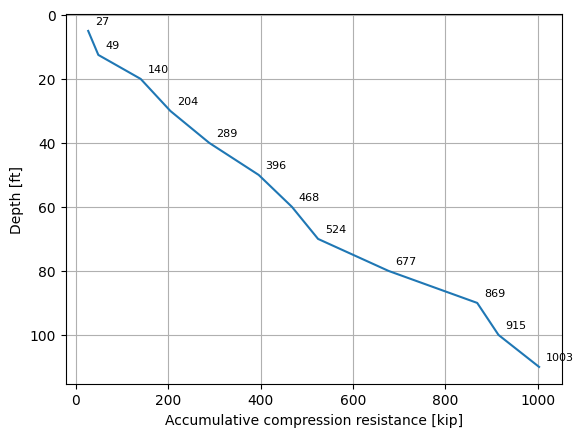

In [23]:
deep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "mid")

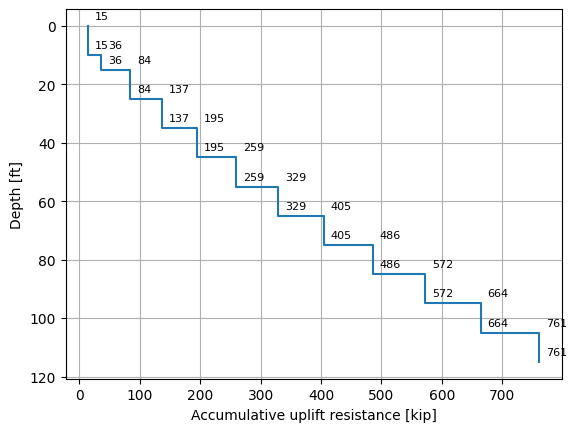

In [24]:
# Test plotting uplift accumulative resistance
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "piecewise")


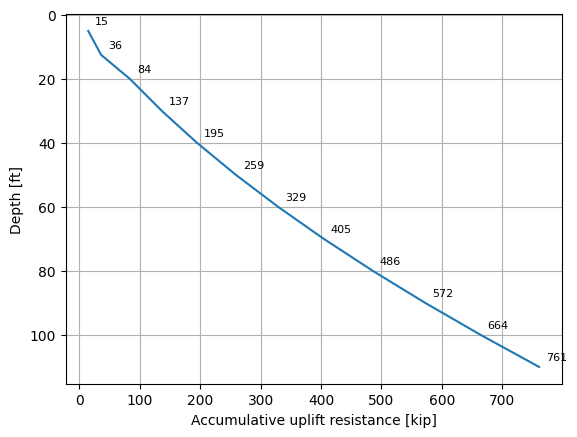

In [25]:
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "mid")

In [26]:
# Test structural compression capacity
print("Each segment's structural capacity in compression is: ")
deep_foundation_obj.segments_structural_capacity_compression()

Each segment's structural capacity in compression is: 


[335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207]

In [27]:
# Test side resistance correction
#deep_foundation_obj = DeepFoundation([segment_obj_1, segment_obj_2], top_depth, resistance_correction=True)
#print(f"With depth correction, second segment side resistance is: {deep_foundation_obj.segments[1].side_resistance}")